In [2]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [3]:
def svg_plot(da,savepath,landmask=False,cmap = "RdBu_r",vmin=np.nan,vcenter=np.nan,vmax=np.nan,cbar=False,norm_map=False):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    # --- 2. Set up the projection ---
    central_lon = 210
    proj = ccrs.Robinson(central_longitude=central_lon)

    fig = plt.figure(figsize=(11, 6))
    ax = plt.axes(projection=proj)

    data = da.data
    if norm_map:
        data = data = data/np.std(data)

    # --- 3. Plot the data ---
    # transform=ccrs.PlateCarree() tells cartopy your data is in regular lat/lon coords
    if not np.isnan(vmin):
        mesh = ax.pcolormesh(
                da.lon, da.lat, data,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                shading="auto",
                norm=mpl.colors.TwoSlopeNorm(vmin=vmin,vcenter=vcenter,vmax=vmax)
            )
    elif not np.isnan(vcenter):
        mag = np.max(np.abs(data))
        mesh = ax.pcolormesh(
            da.lon, da.lat, data,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=mpl.colors.TwoSlopeNorm(vmin=-mag,vcenter=vcenter,vmax=mag),
            shading="auto",
        )
    else:
        mesh = ax.pcolormesh(
            da.lon, da.lat, data,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            shading="auto",
        )

    # --- 4. Add map features ---
    if landmask:
            land = cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='face')
            ax.add_feature(land, facecolor='lightgray')

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_global()  # ensures full globe is shown

    # Optional: gridlines
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)

    # # --- 5. Colorbar ---
    if cbar:
        cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
        cbar.set_label(r"Spatial variance in pattern ($\sigma$)")

    # ax.set_title(f"Robinson Projection Centered at {central_lon}°E", fontsize=13)

    plt.tight_layout()
    # plt.savefig("robinson_plot.png", dpi=200, bbox_inches="tight")

    plt.title(da.name)

    # Make figure and axes backgrounds transparent
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    # Cartopy adds its own background patch for the map outline — clear that too
    # ax.background_patch.set_alpha(0)   # older cartopy versions
    # or, in newer cartopy versions:
    ax.spines['geo'].set_visible(False)  # optional: remove the border/outline too

    # Save as SVG with transparency
    plt.savefig(savepath, format="svg", transparent=True, bbox_inches="tight")
    # plt.show()

In [4]:
cdo = Cdo()
template_path           = '/scratch/leiff/MCA/data/rlut_mon_CanESM5_historical_r1i1p1f1_g025.nc'

In [6]:
filepath_input_era5     = '/rugenstein-archive/senne/data/obs/ERA5/tas_ERA5_194001-202412.nc'
filepath_input_ceres    = '/rugenstein-archive/senne/data/observations/CERES/CERES_EBAF-TOA_Ed4.2.1_Subset_1degx1deg_200003-202604.nc'

In [7]:
xc.open_dataset(filepath_input_era5)

<xarray.Dataset> Size: 8GB
Dimensions:         (time: 1020, latitude: 721, longitude: 1440, bnds: 2)
Coordinates:
  * time            (time) object 8kB 1940-01-01 00:00:00 ... 2024-12-01 00:0...
  * latitude        (latitude) float32 3kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float32 6kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
Dimensions without coordinates: bnds
Data variables:
    t2m             (time, latitude, longitude) float64 8GB ...
    longitude_bnds  (longitude, bnds) float32 12kB -0.125 0.125 ... 359.6 359.9
    latitude_bnds   (latitude, bnds) float32 6kB 90.0 89.88 ... -89.88 -90.0

In [11]:
ceres = xc.open_dataset(filepath_input_ceres).drop_vars(('toa_sw_all_mon','toa_lw_all_mon','toa_sw_clr_c_mon',
        'toa_lw_clr_c_mon','toa_net_clr_c_mon','solar_mon','cldarea_total_daynight_mon','cldpress_total_daynight_mon',
        'cldtemp_total_daynight_mon','cldtau_total_day_mon'))


2026-08-25 15:52:35,846 [WARNING]: dataset.py(decode_time:412) >> 'time' does not have a calendar attribute set. Defaulting to CF 'standard' calendar.


<xarray.Dataset> Size: 81MB
Dimensions:          (time: 314, lat: 180, lon: 360, bnds: 2)
Coordinates:
  * time             (time) object 3kB 2000-03-15 00:00:00 ... 2026-04-15 00:...
  * lat              (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon              (lon) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    toa_net_all_mon  (time, lat, lon) float32 81MB ...
    lon_bnds         (lon, bnds) float32 3kB 0.0 1.0 1.0 ... 359.0 359.0 360.0
    lat_bnds         (lat, bnds) float32 1kB -90.0 -89.0 -89.0 ... 89.0 90.0
Attributes:
    title:        CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Monthly...
    institution:  NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:  CF-1.4
    comment:      Climatology from 07/2005 to 06/2015
    version:      Edition 4.2.1; Release Date November 25, 2024
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF-TOA_L3B004.2.1

In [14]:
# Remapping 
filepath_output_ceres   = '/scratch/leiff/MCA/amip_clean/data/CERES/CERES_net_200003-202604_g025.nc'
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'

cdo.remapcon(template_path,  input =  filepath_input_ceres, output = filepath_output_ceres, options = '-O -s -f nc4c -z zip_4')
cdo.remapcon(template_path,  input =  filepath_input_era5, output = filepath_output_era5, options = '-O -s -f nc4c -z zip_4')



In [25]:
ERA5    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
        "t2m": "tas",})
CERES   = xc.open_dataset(filepath_output_ceres).drop_vars(('toa_sw_all_mon','toa_lw_all_mon','toa_sw_clr_c_mon',
        'toa_lw_clr_c_mon','toa_net_clr_c_mon','solar_mon','cldarea_total_daynight_mon','cldpress_total_daynight_mon',
        'cldtemp_total_daynight_mon','cldtau_total_day_mon')).sel(time=slice('2000-03','2014-12')).rename_vars({
        "toa_net_all_mon": "N",})

In [26]:
ERA5

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 178, lat: 72, lon: 144, bnds: 2)
Coordinates:
  * time      (time) object 1kB 2000-03-01 00:00:00 ... 2014-12-01 00:00:00
  * lat       (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Dimensions without coordinates: bnds
Data variables:
    tas       (time, lat, lon) float32 7MB ...
    lon_bnds  (lon, bnds) float64 2kB 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    lat_bnds  (lat, bnds) float64 1kB -90.0 -87.5 -87.5 -85.0 ... 87.5 87.5 90.0
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Aug 25 16:02:53 2026: cdo -O -s -O -s -f nc4c -z zip_4 ...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [27]:
CERES

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 178, lat: 72, lon: 144, bnds: 2)
Coordinates:
  * time      (time) object 1kB 2000-03-15 00:00:00 ... 2014-12-15 00:00:00
  * lat       (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Dimensions without coordinates: bnds
Data variables:
    N         (time, lat, lon) float32 7MB ...
    lon_bnds  (lon, bnds) float64 2kB 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    lat_bnds  (lat, bnds) float64 1kB -90.0 -87.5 -87.5 -85.0 ... 87.5 87.5 90.0
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.4
    institution:  NASA/LaRC (Langley Research Center) Hampton, Va
    title:        CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Monthly...
    comment:      Climatology from 07/2005 to 06/2015
    version:      Edition 4.2.1; Release Date November 25, 2024
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF-TOA_L3B004.2.1
    history:      Tue Aug 25 16:01:22 2026: cdo -O -s -O -s -f nc4c -z zip_4 ...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [31]:
ERA5['weights'] = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))

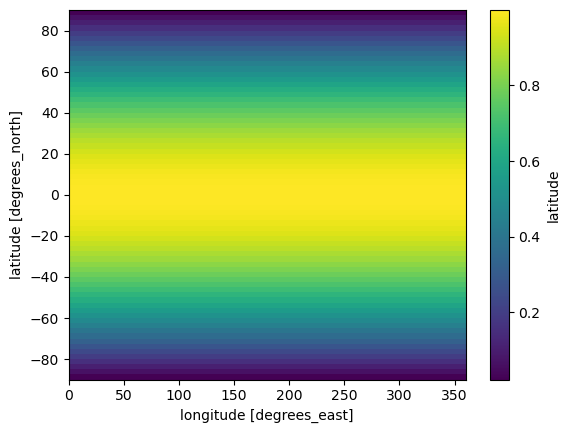

In [32]:
ERA5['weights'].plot()